In [1]:
%matplotlib inline
# notebook - 交互式图形， qt - 独立窗口显示图形
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

## 2D Plot 
[Reference Link](https://www.zhihu.com/tardis/zm/art/139052035?source_id=1003)

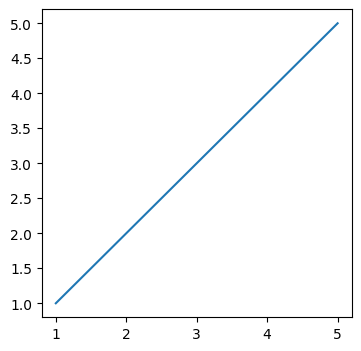

In [15]:
fig = plt.figure(num=1, figsize=(4,4))
plt.plot(np.linspace(1,5), np.linspace(1,5))
plt.show()

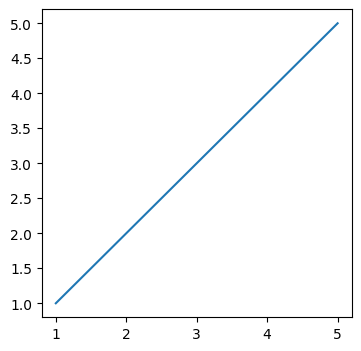

In [7]:
fig = plt.figure(num=1, figsize=(4,4))
ax = fig.add_subplot(111)
ax.plot(np.linspace(1,5), np.linspace(1,5))
plt.show()

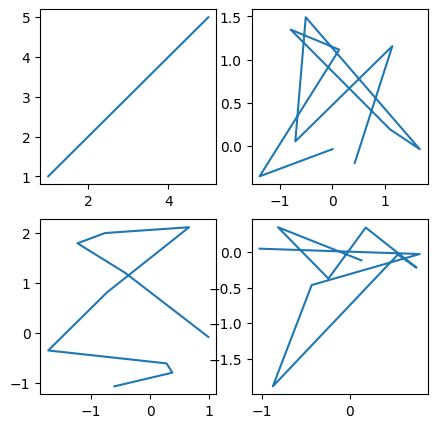

In [43]:
fig = plt.figure(num=1, figsize=(5, 5))

ax1 = fig.add_subplot(221)
ax1.plot(np.linspace(1,5), np.linspace(1,5))
ax2 = fig.add_subplot(222)
ax2.plot(np.random.randn(10), np.random.randn(10))
ax3 = fig.add_subplot(223)
ax3.plot(np.random.randn(10), np.random.randn(10))
ax4 = fig.add_subplot(224)
ax4.plot(np.random.randn(10), np.random.randn(10))
plt.show()


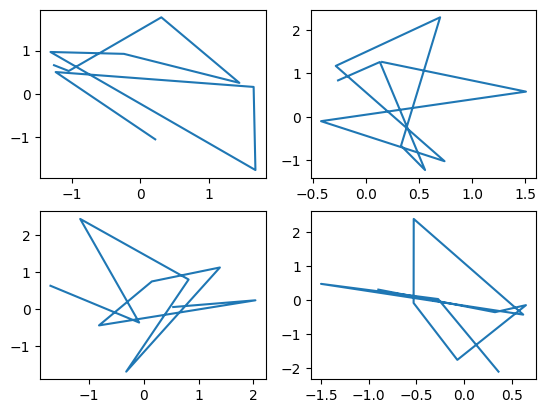

In [10]:
fig, axes = plt.subplots(2,2)

for i in range(2):
    for j in range(2):
        axes[i, j].plot(np.random.randn(10), np.random.randn(10))

plt.show()

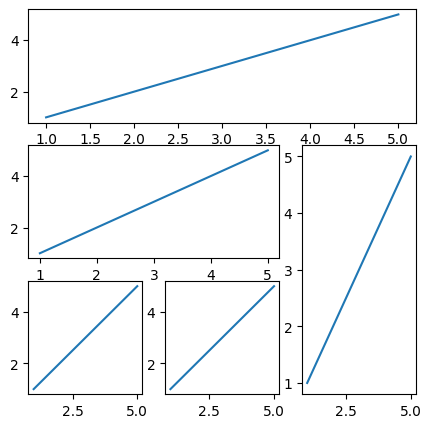

In [28]:
fig = plt.figure(num=1, figsize=(5,5))
gs = gridspec.GridSpec(3,3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(np.linspace(1,5), np.linspace(1,5))
ax2 = fig.add_subplot(gs[1,:-1])
ax2.plot(np.linspace(1,5), np.linspace(1,5))
ax3 = fig.add_subplot(gs[1:, -1])
ax3.plot(np.linspace(1,5), np.linspace(1,5))
ax4 = fig.add_subplot(gs[-1,0])
ax4.plot(np.linspace(1,5), np.linspace(1,5))
ax5 = fig.add_subplot(gs[-1, 1])
ax5.plot(np.linspace(1,5), np.linspace(1,5))

plt.show()


In [13]:
plt.rcParams["font.family"] = "sans-serif"

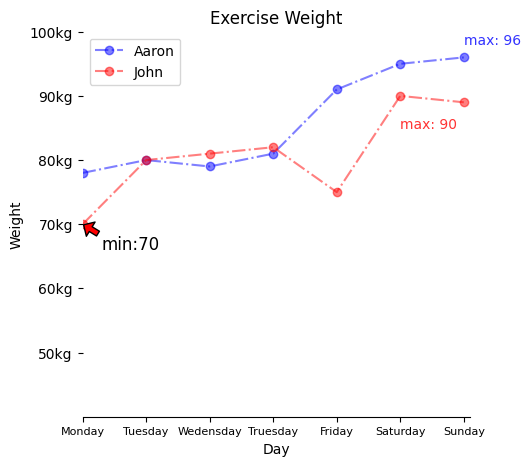

In [48]:
app=[78,80,79,81,91,95,96]
ban=[70,80,81,82,75,90,89]
x=np.arange(1,8)
fig = plt.figure(num=1, figsize=(5,5))

# plot data 
ax = fig.add_subplot(111)
ax.plot(x, app, 'b-.o', label = "Aaron", alpha=0.5)
ax.plot(x, ban, 'r-.o', label = "John", alpha=0.5)
ax.text(7, 98, "max: 96", color = 'b', alpha = 0.8)
ax.text(6, 85, "max: 90", color = 'r', alpha=0.8)
ax.annotate("min:70",xy=(1,70),xytext=(1.3,66),arrowprops=dict(facecolor="r",shrink=0.05,headwidth=12,headlength=6,width=4),fontsize=12)

# control range of the axis
ax.set_xlim([1, 7.1])
ax.set_ylim([40, 100])

# assign labels on the axis
ax.set_xticks(np.linspace(1,7,7))
ax.set_yticks(np.linspace(50,100,6))
ax.set_xticklabels(["Monday", "Tuesday", "Wedensday", "Truesday", "Friday", "Saturday", "Sunday"], fontsize=8)
ax.set_yticklabels(["50kg", '60kg', '70kg', '80kg', '90kg', '100kg'])

# set label of the axis, title of graph and lengend
ax.set_xlabel("Day")
ax.set_ylabel("Weight")
ax.set_title("Exercise Weight")

# set visible of the border line 
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc = "best")

plt.savefig("excercise_weight.jpg", bbox_inches = 'tight') # put in front of plt.show()
plt.show()


## 2D Animation

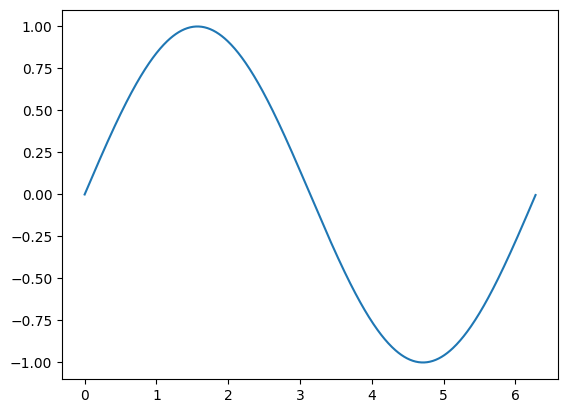

In [6]:
from matplotlib import animation

fig, ax = plt.subplots()

x = np.arange(0, 2*np.pi, 0.01)
line, =ax.plot(x, np.sin(x))

def animate(i):
    line.set_ydata(np.sin(x+i/100))
    return line,

def init():
    line.set_ydata(np.sin(x))
    return line,

ani = animation.FuncAnimation(fig=fig, func=animate, frames=100, init_func=init, interval=20, blit=False)

plt.show()

/tmp/ipykernel_1568/1677566014.py:38: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  FuncAnimation(


KeyboardInterrupt: 

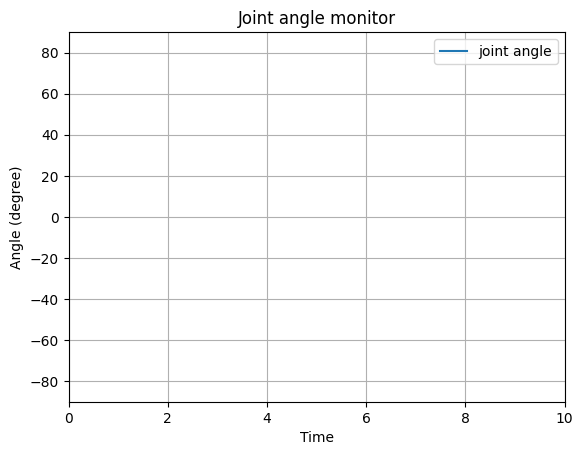

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import time

fig, ax = plt.subplots()
time_data = []
joint_data = []
line, = ax.plot([], [], label="joint angle")
ax.set_xlim([0, 10])
ax.set_ylim([-90, 90])
ax.set_xlabel("Time")
ax.set_ylabel("Angle (degree)")
ax.set_title("Joint angle monitor")
ax.legend()
ax.grid(True)

def read_joint_angle():
    '''API for reading angle from robot'''
    return np.random.uniform(-10,10)


start = time.time()
def animate():
    '''animate plot of data'''
    current_time = start - time.time()
    joint_angle = read_joint_angle()
    
    time_data.append(current_time)
    joint_data.append(joint_angle)
    
    line.set_data(time_data, joint_data)
    
    # reset the range of x axis
    if current_time > ax.get_xlim()[1]:
        ax.set_xlim(0, current_time + 5)
        
    return line,

FuncAnimation(
    fig=fig,
    func=animate,
    interval=100,
    blit=False
    
)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import time

fig, ax = plt.subplots()
time_data = []
joint_data = []
line, = ax.plot([], [], label="joint angle")
ax.set_xlim([0, 10])
ax.set_ylim([-90, 90])
ax.set_xlabel("Time")
ax.set_ylabel("Angle (degree)")
ax.set_title("Joint angle monitor")
ax.legend()
ax.grid(True)

animation_running = True

def read_joint_angle():
    '''API for reading angle from robot'''
    return np.random.uniform(-10,10)


start = time.time()
def animate():
    '''animate plot of data'''
    if not animation_running:
        return line,
    
    current_time = start - time.time()
    joint_angle = read_joint_angle()
    
    time_data.append(current_time)
    joint_data.append(joint_angle)
    
    line.set_data(time_data, joint_data)
    
    # reset the range of x axis
    if current_time > ax.get_xlim()[1]:
        ax.set_xlim(0, current_time + 5)
        
    return line,

def toggle_animation(event):
    global animation_running
    if event.key == "p":
        animation_running = not animation_running

FuncAnimation(
    fig=fig,
    func=animate,
    interval=100,
    blit=False
    
)

plt.canvas.mpl_connect("key_press_event", toggle_animation)

plt.show()

## 3D Plot
[Reference Link](http://pythonmatplotlib.baoshu.red/%E4%B8%89%E7%BB%B4%E5%9B%BE.html#)

In [5]:
from mpl_toolkits import mplot3d

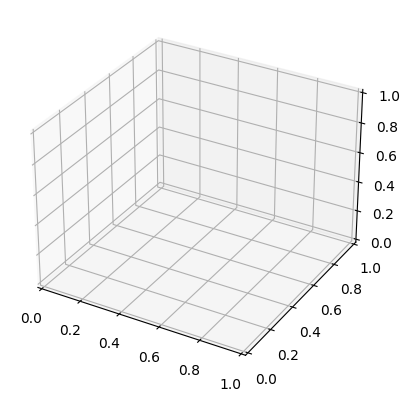

In [54]:
ax = plt.axes(projection='3d')

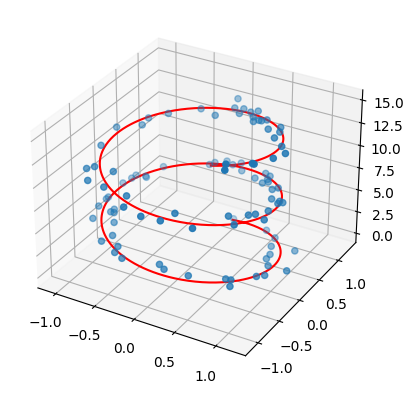

In [53]:
ax = plt.axes(projection='3d')

z = np.linspace(0, 15, 1000)
x = np.sin(z)
y = np.cos(z)

# plot 3d line 
ax.plot3D(x, y, z, 'r')

# scatter 3d points
zdata = 15 * np.random.random(100)
xdata = np.sin(zdata) + 0.1 * np.random.randn(100)
ydata = np.cos(zdata) + 0.1 * np.random.randn(100)
ax.scatter(xdata, ydata, zdata)

plt.show()

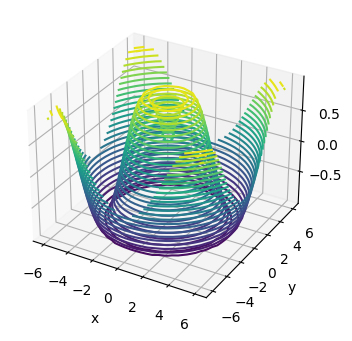

In [17]:
def f(x, y):
    return np.sin(np.sqrt(x**2 + y**2))

x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(4,4))
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z, 30) # num of contour line

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

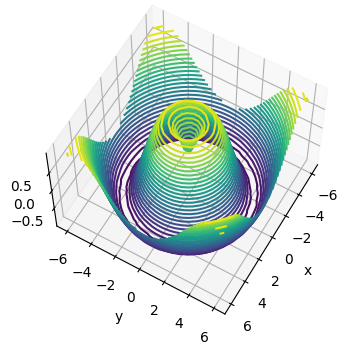

In [19]:
ax.view_init(60, 30) # 第一个参数： 与xy平面所成的角，第二个参数：绕z轴旋转的角度
fig

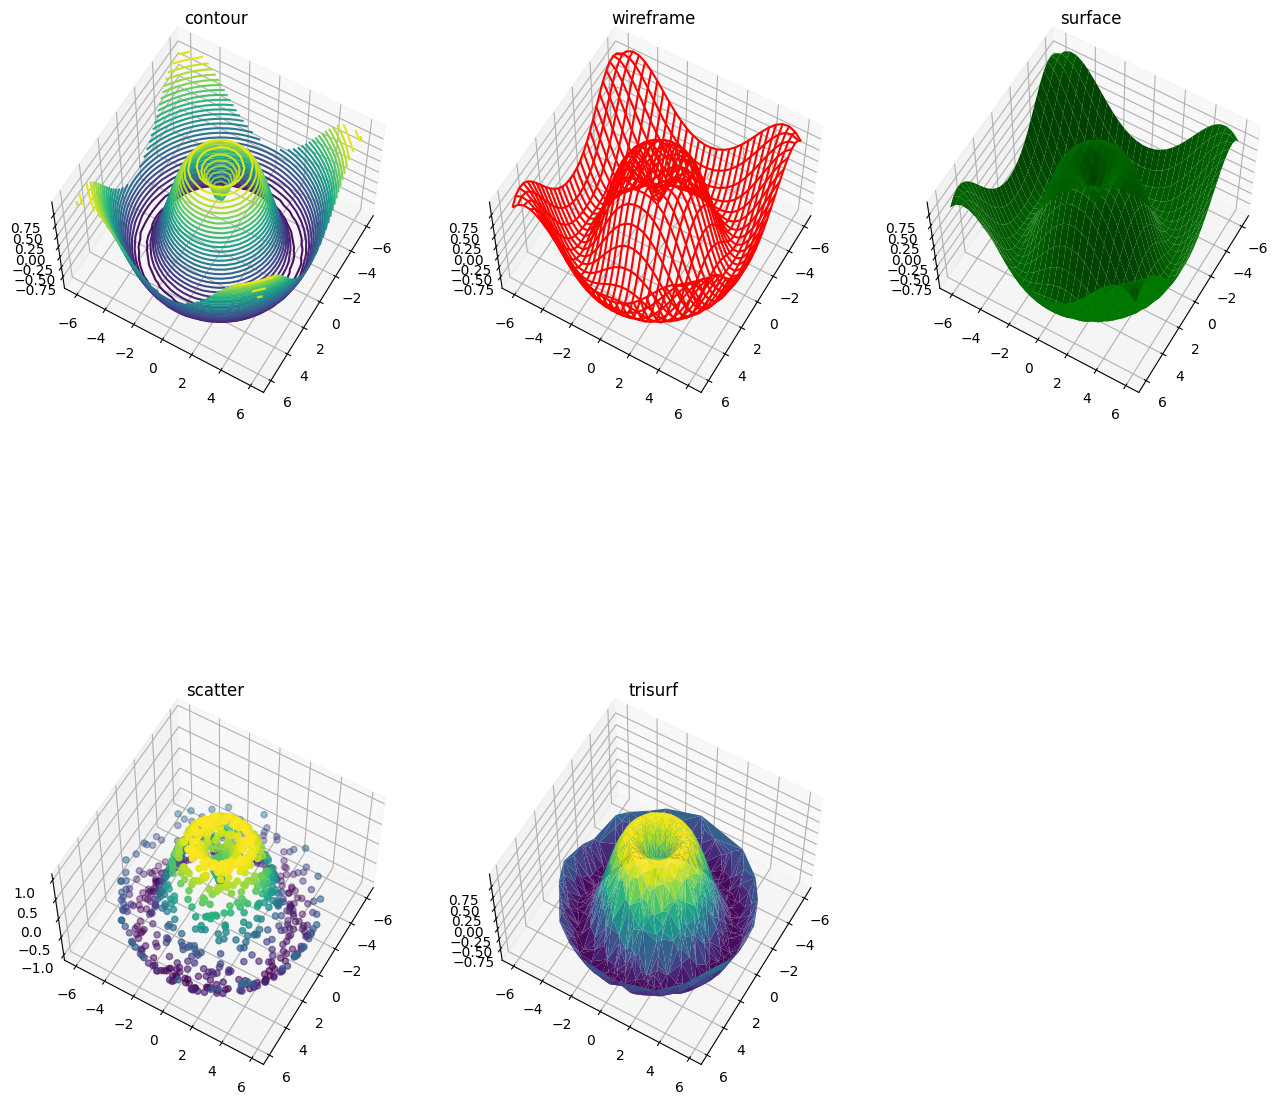

In [44]:
fig = plt.figure(num=1, figsize=(16, 16))

ax1 = fig.add_subplot(231, projection='3d')
ax1.contour3D(X, Y, Z, 30)
ax1.set_title('contour')

ax2 = fig.add_subplot(232, projection='3d')
ax2.plot_wireframe(X, Y, Z, color='red') 
ax2.set_title('wireframe')

ax3 = fig.add_subplot(233, projection='3d')
ax3.plot_surface(X, Y, Z, color = 'green')
ax3.set_title('surface')

theta = 2 * np.pi * np.random.random(1000)
r = 6 * np.random.random(1000)
x = np.ravel(r * np.sin(theta))
y = np.ravel(r * np.cos(theta))
z = f(x, y)

ax4 =  fig.add_subplot(234, projection='3d')
ax4.scatter(x, y, z, c=z, cmap='viridis', linewidth=1)
ax4.set_title('scatter')

ax5 = fig.add_subplot(235, projection='3d')
ax5.plot_trisurf(x, y, z, cmap='viridis', edgecolor='none')
ax5.set_title('trisurf')

# Set view for all plots
axes = [ax1, ax2, ax3, ax4, ax5]
for ax in axes:
    ax.view_init(60, 30)